<a href="https://colab.research.google.com/github/StephPendle/Forecasting-/blob/main/Forecast_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install pandas numpy scikit-learn tensorflow keras matplotlib seaborn streamlit pandas-profiling xgboost statsmodels
!pip install gym stable-baselines3 # For reinforcement learning components

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import gym
from gym import spaces
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pandas-profiling to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.0/103.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 54.4 MB/s eta 0:00:00
  Created wheel f

In [ ]:
# Function to generate dummy data
def generate_dummy_data(n_samples=1000):
    # Date range for the past 3 years
    end_date = datetime.now()
    start_date = end_date - timedelta(days=3*365)
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')

    # Select random dates from the range
    dates = np.random.choice(date_range, n_samples)
    dates = sorted(dates)

    # Store and product IDs
    store_ids = np.random.randint(1, 11, n_samples)  # 10 stores
    product_ids = np.random.randint(1, 101, n_samples)  # 100 products

    # Base demand with seasonality
    t = np.arange(n_samples)
    base_demand = 100 + 20 * np.sin(2 * np.pi * t / 365)  # Yearly seasonality
    base_demand += 10 * np.sin(2 * np.pi * t / 7)  # Weekly seasonality

    # Add trend
    trend = np.linspace(0, 30, n_samples)
    base_demand += trend

    # Weather features (temperature, precipitation, humidity)
    temperature = 15 + 10 * np.sin(2 * np.pi * t / 365) + np.random.normal(0, 3, n_samples)
    precipitation = np.random.exponential(2, n_samples)
    humidity = 60 + 20 * np.random.random(n_samples)

    # Price and promotion features
    base_price = np.random.uniform(10, 100, n_samples)
    discount_pct = np.random.choice([0, 0, 0, 0.1, 0.2, 0.3, 0.5], n_samples)
    price = base_price * (1 - discount_pct)
    promotion = np.random.choice([0, 1], n_samples, p=[0.8, 0.2])

    # Social media sentiment (normalized between -1 and 1)
    sentiment = np.random.normal(0.2, 0.3, n_samples)
    sentiment = np.clip(sentiment, -1, 1)

    # Special events (holidays, etc.)
    special_event = np.random.choice([0, 1], n_samples, p=[0.95, 0.05])

    # Competitor price
    competitor_price = base_price * np.random.uniform(0.8, 1.2, n_samples)

    # Calculate final demand
    demand = base_demand.copy()

    # Effect of price (higher price reduces demand)
    price_effect = -0.3 * (price / base_price - 1)
    demand *= (1 + price_effect)

    # Effect of promotion (increases demand)
    promotion_effect = 0.5 * promotion
    demand *= (1 + promotion_effect)

    # Effect of weather (temperature has an inverted U relationship with demand)
    temp_effect = -0.002 * (temperature - 20)**2
    demand *= (1 + temp_effect)

    # Effect of sentiment (positive sentiment increases demand)
    sentiment_effect = 0.2 * sentiment
    demand *= (1 + sentiment_effect)

    # Effect of special events
    event_effect = 0.3 * special_event
    demand *= (1 + event_effect)

    # Add noise
    demand += np.random.normal(0, 10, n_samples)
    demand = np.maximum(demand, 0)  # Ensure non-negative demand

    # Create DataFrame
    df = pd.DataFrame({
        'date': dates,
        'store_id': store_ids,
        'product_id': product_ids,
        'temperature': temperature,
        'precipitation': precipitation,
        'humidity': humidity,
        'base_price': base_price,
        'discount_pct': discount_pct,
        'price': price,
        'promotion': promotion,
        'sentiment': sentiment,
        'special_event': special_event,
        'competitor_price': competitor_price,
        'demand': np.round(demand)
    })

    # Add day of week, month, and year features
    df['date'] = pd.to_datetime(df['date'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['day'] = df['date'].dt.day

    # Sort by date, store, and product
    df = df.sort_values(['date', 'store_id', 'product_id']).reset_index(drop=True)

    return df

# Generate dummy data
data = generate_dummy_data(5000)

# Display the first few rows
print(data.head())

# Basic statistics
print(data.describe())

# Check for missing values
print(data.isnull().sum())


                        date  store_id  product_id  temperature  \
0 2022-04-15 17:02:52.703523         1          30    14.090821   
1 2022-04-15 17:02:52.703523         2          76    14.089043   
2 2022-04-15 17:02:52.703523         3          51    15.022027   
3 2022-04-15 17:02:52.703523         5           2    15.509924   
4 2022-04-15 17:02:52.703523         6          12    18.176727   

   precipitation   humidity  base_price  discount_pct      price  promotion  \
0       2.225427  66.833967   15.579994           0.5   7.789997          0   
1       3.564265  61.882935   45.887438           0.3  32.121206          0   
2       1.332176  78.707390   64.408116           0.0  64.408116          0   
3       0.209151  60.092199   22.668780           0.3  15.868146          1   
4       0.377889  64.475446   31.632383           0.5  15.816192          0   

   sentiment  special_event  competitor_price  demand  day_of_week  month  \
0   0.581828              0         16.572846

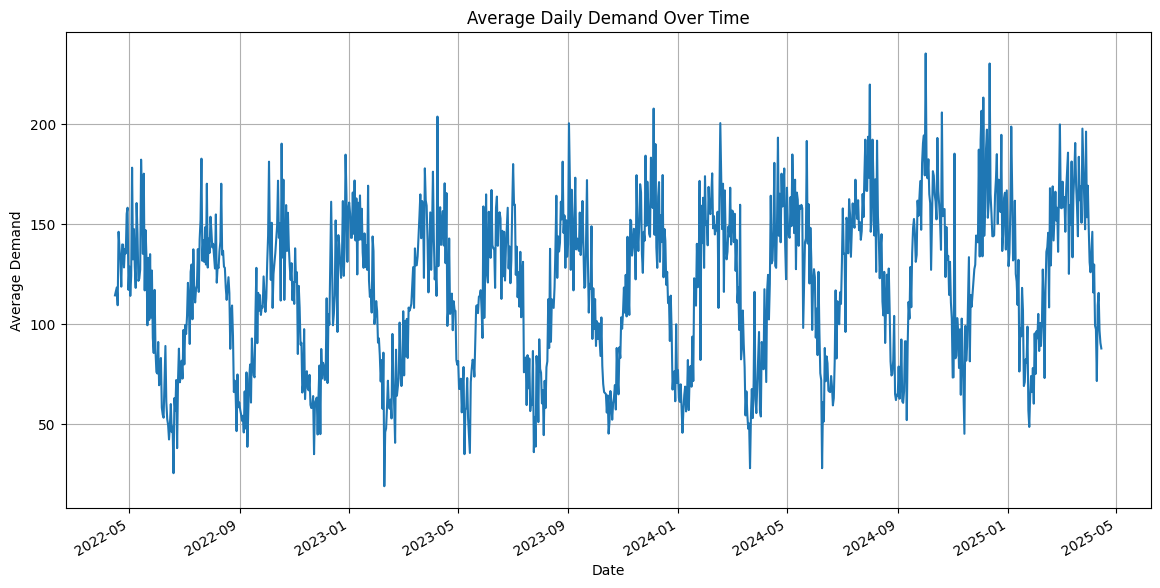

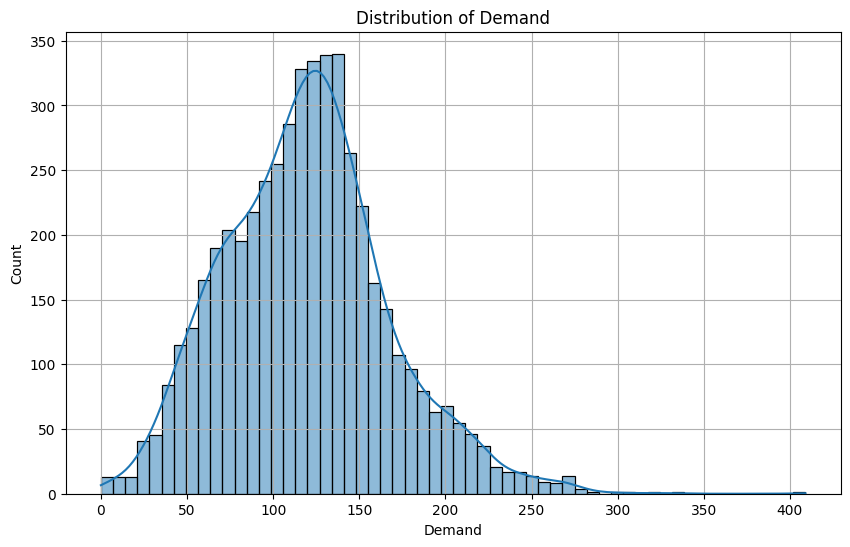

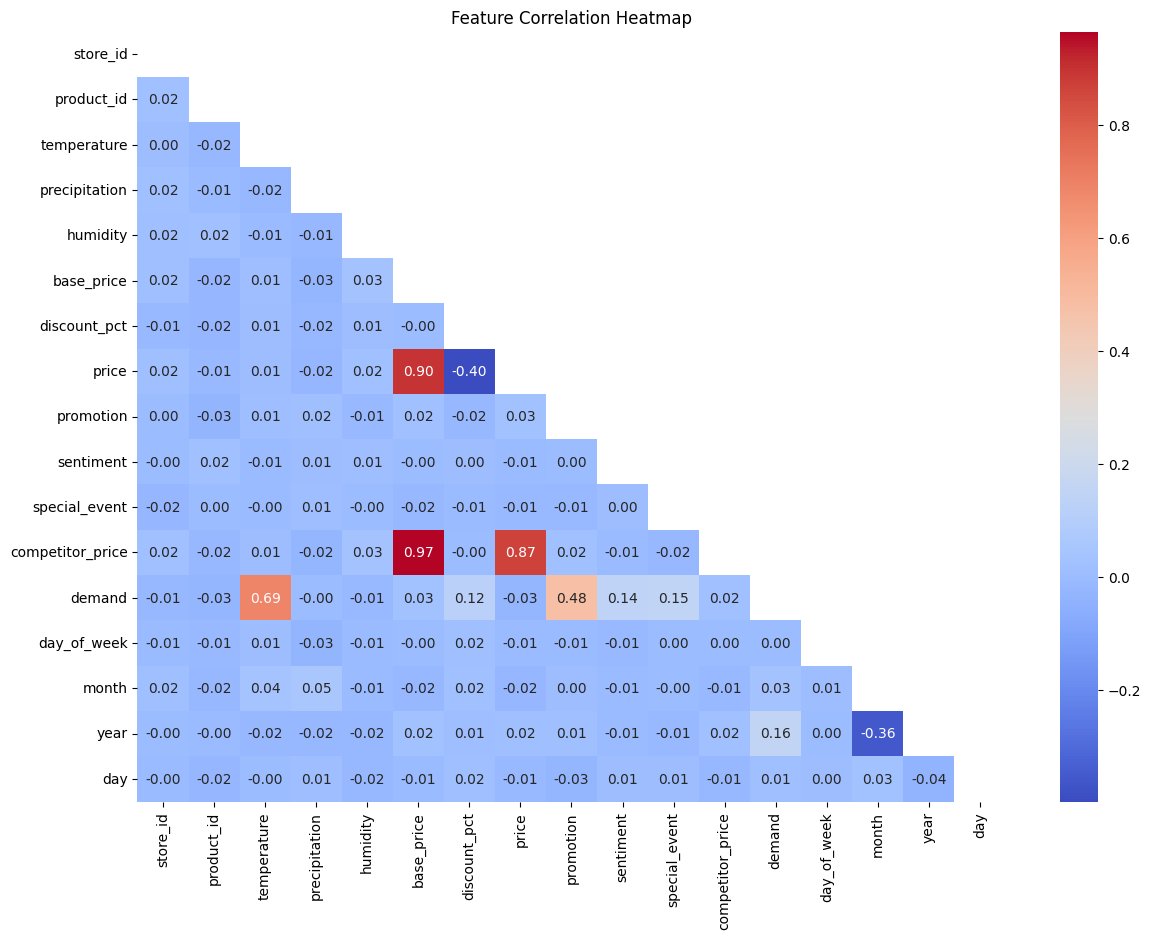

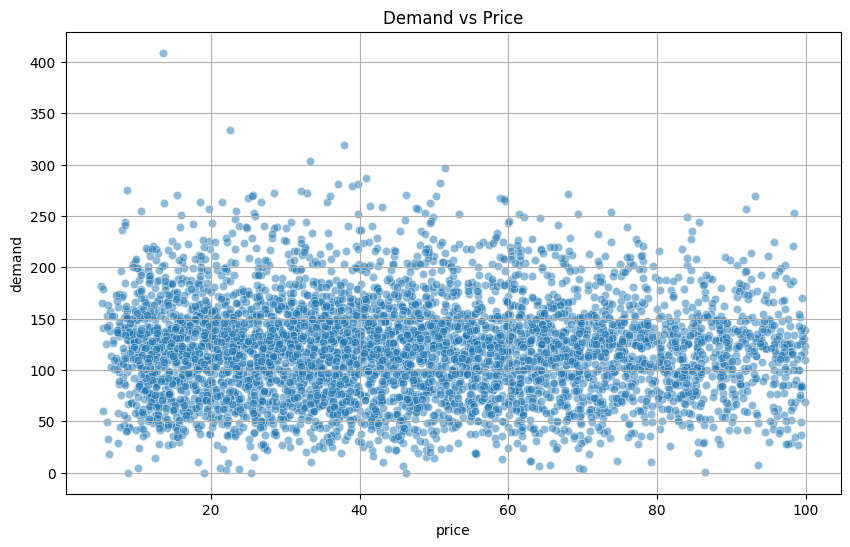

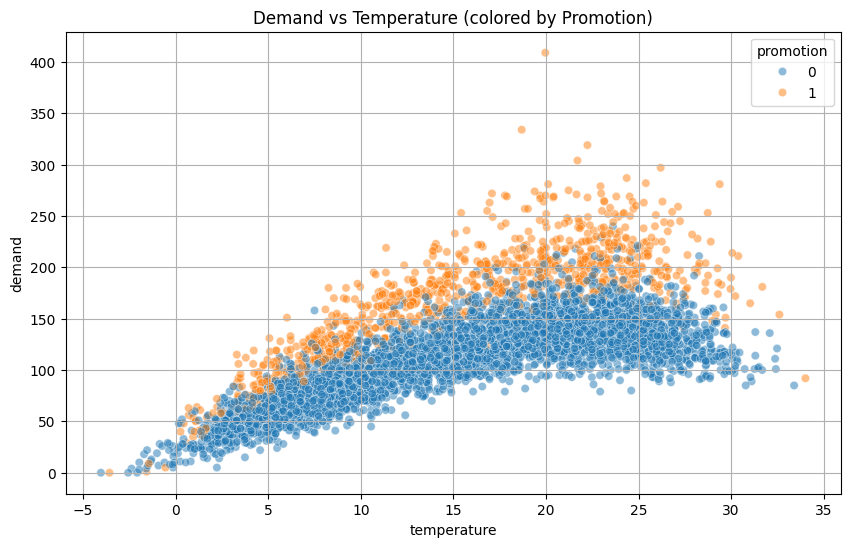

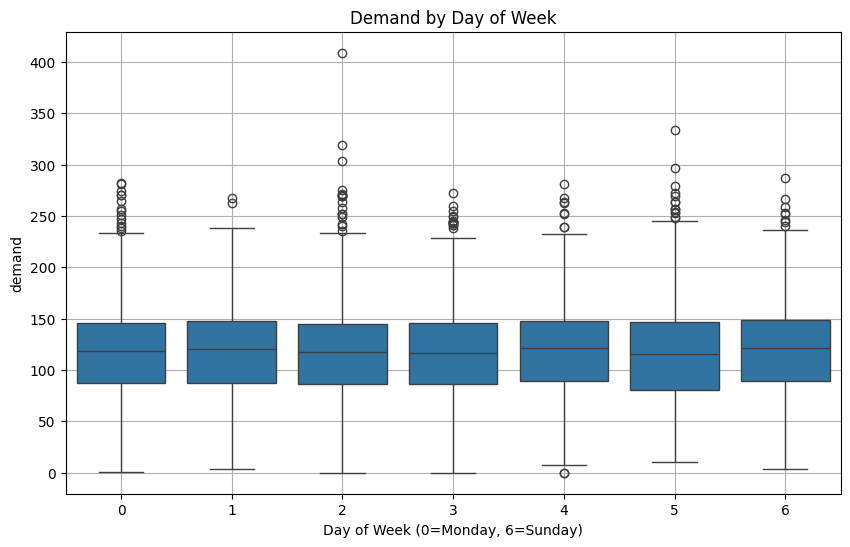

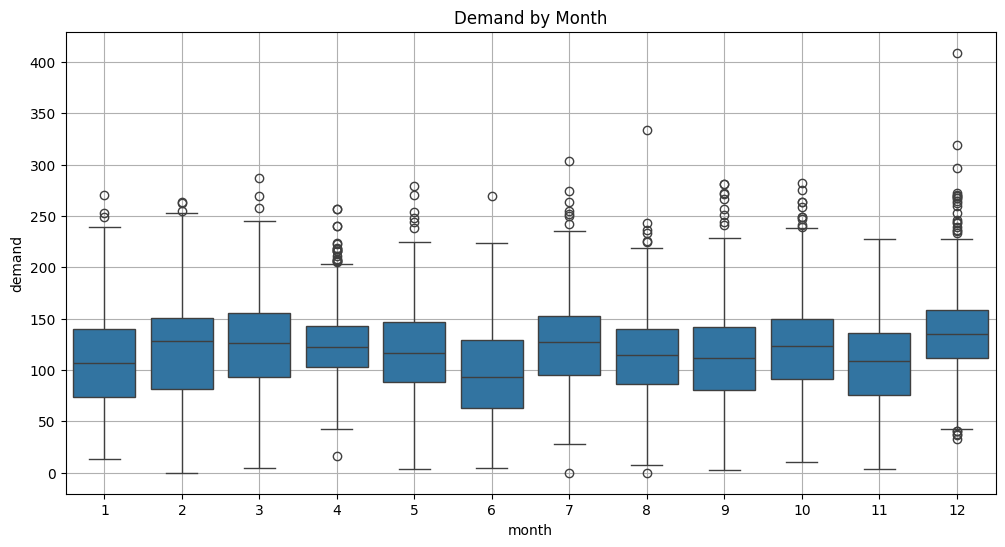

In [ ]:
# Plot demand over time
plt.figure(figsize=(14, 7))
data.groupby('date')['demand'].mean().plot()
plt.title('Average Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Average Demand')
plt.grid(True)
plt.show()

# Distribution of demand
plt.figure(figsize=(10, 6))
sns.histplot(data['demand'], kde=True)
plt.title('Distribution of Demand')
plt.xlabel('Demand')
plt.grid(True)
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation = data.select_dtypes(include=[np.number]).corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
plt.title('Feature Correlation Heatmap')
plt.show()

# Demand vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='demand', data=data, alpha=0.5)
plt.title('Demand vs Price')
plt.grid(True)
plt.show()

# Demand vs Temperature with Promotion
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='demand', hue='promotion', data=data, alpha=0.5)
plt.title('Demand vs Temperature (colored by Promotion)')
plt.grid(True)
plt.show()

# Demand by Day of Week
plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='demand', data=data)
plt.title('Demand by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.grid(True)
plt.show()

# Demand by Month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='demand', data=data)
plt.title('Demand by Month')
plt.grid(True)
plt.show()


In [ ]:
def preprocess_data(df, target_col='demand', test_size=0.2, validation_size=0.1):
    """
    Preprocess the data for time series forecasting.

    Parameters:
    -----------
    df : pandas DataFrame
        The input data
    target_col : str
        The name of the target column
    test_size : float
        The proportion of data to use for testing
    validation_size : float
        The proportion of training data to use for validation

    Returns:
    --------
    Tuple of preprocessed data splits and scalers
    """
    # Create a copy of the dataframe
    data = df.copy()

    print(f"Original data shape: {data.shape}")

    # Convert date to datetime if not already
    if not pd.api.types.is_datetime64_any_dtype(data['date']):
        data['date'] = pd.to_datetime(data['date'])

    # Sort by date
    data = data.sort_values('date').reset_index(drop=True)

    # Create time-based features
    data['day_of_week'] = data['date'].dt.dayofweek
    data['month'] = data['date'].dt.month
    data['year'] = data['date'].dt.year
    data['day'] = data['date'].dt.day
    data['day_of_year'] = data['date'].dt.dayofyear

    # One-hot encode categorical variables
    categorical_cols = ['store_id', 'product_id', 'day_of_week', 'month']
    for col in categorical_cols:
        if col in data.columns:
            dummies = pd.get_dummies(data[col], prefix=col, drop_first=False)
            data = pd.concat([data, dummies], axis=1)

    # Create lag features for the target - but with a more careful approach
    # First, ensure we have enough data for each store-product combination
    store_product_counts = data.groupby(['store_id', 'product_id']).size()
    min_count = store_product_counts.min()
    print(f"Minimum number of records per store-product: {min_count}")

    # Only create lag features if we have enough data
    max_lag = 7  # Reduced from 28 to avoid too many NaNs
    if min_count > max_lag:
        for lag in range(1, max_lag + 1):
            data[f'{target_col}_lag_{lag}'] = data.groupby(['store_id', 'product_id'])[target_col].shift(lag)

        # Create rolling mean features with smaller windows
        for window in [3, 7]:
            data[f'{target_col}_rolling_mean_{window}'] = data.groupby(['store_id', 'product_id'])[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
    else:
        print("Not enough data for lag features. Using simpler features.")
        # Add simpler features that don't require as much history
        data[f'{target_col}_lag_1'] = data.groupby(['store_id', 'product_id'])[target_col].shift(1)
        data[f'{target_col}_rolling_mean_3'] = data.groupby(['store_id', 'product_id'])[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())

    print(f"Data shape before handling NaN: {data.shape}")
    print(f"NaN counts:\n{data.isna().sum().sum()}")

    # Instead of dropping NaN rows, fill them with appropriate values
    # Fill NaN values in lag features
    lag_cols = [col for col in data.columns if '_lag_' in col or '_rolling_mean_' in col]
    for col in lag_cols:
        # Fill with the mean of non-NaN values for each store-product combination
        data[col] = data.groupby(['store_id', 'product_id'])[col].transform(
            lambda x: x.fillna(x.mean()))
        # If any NaNs remain (e.g., for new products), fill with overall mean
        if data[col].isna().any():
            data[col] = data[col].fillna(data[col].mean())
            # If still NaN (e.g., all values for a group are NaN), fill with 0
            data[col] = data[col].fillna(0)

    print(f"Data shape after handling NaN: {data.shape}")
    print(f"Remaining NaN counts: {data.isna().sum().sum()}")

    # Check if we have enough data
    if len(data) == 0:
        raise ValueError("After preprocessing, no data remains. Check your data generation and preprocessing steps.")

    # Define features and target
    # Exclude the original categorical columns that were one-hot encoded
    features = data.drop(['date', target_col, 'store_id', 'product_id', 'day_of_week', 'month'], axis=1)
    target = data[target_col]

    # Ensure we have enough data for splitting
    min_samples_required = 10  # Arbitrary minimum
    if len(data) < min_samples_required:
        raise ValueError(f"Not enough samples ({len(data)}) for meaningful train/test split. Need at least {min_samples_required}.")

    # Split data into train, validation, and test sets
    # Use a fixed number of samples for test if percentage would result in too few samples
    if len(data) * test_size < 2:
        test_size = 2 / len(data)  # Ensure at least 2 samples in test set
        print(f"Adjusted test_size to {test_size} to ensure minimum test samples")

    # First, split into train+validation and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        features, target, test_size=test_size, shuffle=False, random_state=42)

    # Then split train+validation into train and validation
    val_size_adjusted = validation_size / (1 - test_size)
    if len(X_train_val) * val_size_adjusted < 2:
        val_size_adjusted = 2 / len(X_train_val)  # Ensure at least 2 samples in validation set
        print(f"Adjusted validation_size to {val_size_adjusted} to ensure minimum validation samples")

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size_adjusted, shuffle=False, random_state=42)

    print(f"Train set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples")
    print(f"Test set: {len(X_test)} samples")

    # Scale numerical features
    scaler = StandardScaler()
    numerical_cols = features.select_dtypes(include=[np.number]).columns

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    # Scale target for neural network models
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    return (X_train_scaled, X_val_scaled, X_test_scaled,
            y_train, y_val, y_test,
            y_train_scaled, y_val_scaled, y_test_scaled,
            scaler, target_scaler)


In [ ]:
def preprocess_data(df, target_col='demand', test_size=0.2, validation_size=0.1):
    """
    Preprocess data for demand forecasting with robust error handling.
    """
    # Create a copy of the dataframe
    data = df.copy()

    print(f"Original data shape: {data.shape}")

    # Convert date to datetime if not already
    if not pd.api.types.is_datetime64_any_dtype(data['date']):
        data['date'] = pd.to_datetime(data['date'])

    # Sort by date
    data = data.sort_values('date').reset_index(drop=True)

    # Create time-based features
    data['day_of_week'] = data['date'].dt.dayofweek
    data['month'] = data['date'].dt.month
    data['year'] = data['date'].dt.year
    data['day'] = data['date'].dt.day
    data['day_of_year'] = data['date'].dt.dayofyear

    # One-hot encode categorical variables
    categorical_cols = ['store_id', 'product_id', 'day_of_week', 'month']
    for col in categorical_cols:
        if col in data.columns:
            dummies = pd.get_dummies(data[col], prefix=col, drop_first=False)
            data = pd.concat([data, dummies], axis=1)

    # Create simpler lag features that won't eliminate too many rows
    # Only use lag-1 to minimize data loss
    data[f'{target_col}_lag_1'] = data.groupby(['store_id', 'product_id'])[target_col].shift(1)

    # Create a simple rolling mean with a small window
    data[f'{target_col}_rolling_mean_3'] = data.groupby(['store_id', 'product_id'])[target_col].transform(
        lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())

    print(f"Data shape before handling NaN: {data.shape}")
    print(f"NaN counts: {data.isna().sum().sum()}")

    # Fill NaN values instead of dropping rows
    lag_cols = [col for col in data.columns if '_lag_' in col or '_rolling_mean_' in col]
    for col in lag_cols:
        # Fill with the mean of the column
        data[col] = data[col].fillna(data[col].mean())
        # If still NaN (e.g., all values are NaN), fill with 0
        data[col] = data[col].fillna(0)

    print(f"Data shape after handling NaN: {data.shape}")
    print(f"Remaining NaN counts: {data.isna().sum().sum()}")

    # Define features and target
    # Make sure to exclude the original categorical columns that were one-hot encoded
    features = data.drop(['date', target_col, 'store_id', 'product_id', 'day_of_week', 'month'], axis=1)
    target = data[target_col]

    # Verify we have data before splitting
    if len(data) == 0:
        raise ValueError("After preprocessing, no data remains. Check your data generation.")

    print(f"Number of samples for splitting: {len(features)}")

    # Split data into train, validation, and test sets
    # First, split into train+validation and test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        features, target, test_size=test_size, shuffle=False, random_state=42)

    # Then split train+validation into train and validation
    val_size_adjusted = validation_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size_adjusted, shuffle=False, random_state=42)

    print(f"Train set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples")
    print(f"Test set: {len(X_test)} samples")

    # Scale numerical features
    scaler = StandardScaler()
    numerical_cols = features.select_dtypes(include=[np.number]).columns

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

    # Scale target for neural network models
    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()
    y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    return (X_train_scaled, X_val_scaled, X_test_scaled,
            y_train, y_val, y_test,
            y_train_scaled, y_val_scaled, y_test_scaled,
            scaler, target_scaler)


In [ ]:
def generate_dummy_data(n_samples=10000, n_stores=5, n_products=10):
    """
    Generate dummy data with continuous dates for each store-product combination.
    """
    # Create a continuous date range
    end_date = datetime.now()
    start_date = end_date - timedelta(days=365)  # 1 year of data
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')

    # Create all combinations of dates, stores, and products
    dates = []
    store_ids = []
    product_ids = []

    for date in date_range:
        for store in range(1, n_stores + 1):
            for product in range(1, n_products + 1):
                dates.append(date)
                store_ids.append(store)
                product_ids.append(product)

    # Create DataFrame with all combinations
    df = pd.DataFrame({
        'date': dates,
        'store_id': store_ids,
        'product_id': product_ids
    })

    # Limit to n_samples if needed
    if len(df) > n_samples:
        df = df.sample(n_samples, random_state=42).reset_index(drop=True)

    # Sort by date, store, and product
    df = df.sort_values(['date', 'store_id', 'product_id']).reset_index(drop=True)

    # Base demand with seasonality
    t = np.arange(len(df))
    base_demand = 100 + 20 * np.sin(2 * np.pi * t / 365)  # Yearly seasonality

    # Add weekly seasonality based on day of week
    df['dow'] = pd.to_datetime(df['date']).dt.dayofweek
    weekly_effect = 10 * np.sin(2 * np.pi * df['dow'] / 7)
    base_demand += weekly_effect

    # Add trend
    trend = np.linspace(0, 30, len(df))
    base_demand += trend

    # Weather features
    df['temperature'] = 15 + 10 * np.sin(2 * np.pi * t / 365) + np.random.normal(0, 3, len(df))
    df['precipitation'] = np.random.exponential(2, len(df))
    df['humidity'] = 60 + 20 * np.random.random(len(df))

    # Price and promotion features
    df['base_price'] = np.random.uniform(10, 100, len(df))
    df['discount_pct'] = np.random.choice([0, 0, 0, 0.1, 0.2, 0.3, 0.5], len(df))
    df['price'] = df['base_price'] * (1 - df['discount_pct'])
    df['promotion'] = np.random.choice([0, 1], len(df), p=[0.8, 0.2])

    # Social media sentiment
    df['sentiment'] = np.random.normal(0.2, 0.3, len(df))
    df['sentiment'] = np.clip(df['sentiment'], -1, 1)

    # Special events and competitor price
    df['special_event'] = np.random.choice([0, 1], len(df), p=[0.95, 0.05])
    df['competitor_price'] = df['base_price'] * np.random.uniform(0.8, 1.2, len(df))

    # Calculate final demand
    demand = base_demand.copy()

    # Effect of price
    price_effect = -0.3 * (df['price'] / df['base_price'] - 1)
    demand *= (1 + price_effect)

    # Effect of promotion
    promotion_effect = 0.5 * df['promotion']
    demand *= (1 + promotion_effect)

    # Effect of weather
    temp_effect = -0.002 * (df['temperature'] - 20)**2
    demand *= (1 + temp_effect)

    # Effect of sentiment
    sentiment_effect = 0.2 * df['sentiment']
    demand *= (1 + sentiment_effect)

    # Effect of special events
    event_effect = 0.3 * df['special_event']
    demand *= (1 + event_effect)

    # Add noise
    demand += np.random.normal(0, 10, len(df))
    demand = np.maximum(demand, 0)  # Ensure non-negative demand

    # Add to DataFrame
    df['demand'] = np.round(demand)

    # Drop temporary column
    df = df.drop('dow', axis=1)

    print(f"Generated data shape: {df.shape}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Number of stores: {df['store_id'].nunique()}")
    print(f"Number of products: {df['product_id'].nunique()}")

    return df


In [ ]:
# Generate data with the improved function
data = generate_dummy_data(n_samples=10000, n_stores=5, n_products=10)

# Process the data with the improved function
try:
    (X_train, X_val, X_test,
     y_train, y_val, y_test,
     y_train_scaled, y_val_scaled, y_test_scaled,
     feature_scaler, target_scaler) = preprocess_data(data)

    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    print(f"Test set shape: {X_test.shape}")

except ValueError as e:
    print(f"Error in preprocessing: {e}")
    # Implement a fallback preprocessing if needed


Generated data shape: (10000, 14)
Date range: 2024-04-14 17:19:45.645559 to 2025-04-14 17:19:45.645559
Number of stores: 5
Number of products: 10
Original data shape: (10000, 14)
Data shape before handling NaN: (10000, 55)
NaN counts: 100
Data shape after handling NaN: (10000, 55)
Remaining NaN counts: 0
Number of samples for splitting: 10000
Train set: 7000 samples
Validation set: 1000 samples
Test set: 2000 samples
Training set shape: (7000, 49)
Validation set shape: (1000, 49)
Test set shape: (2000, 49)


In [ ]:
# Define a custom gym environment for inventory management
class InventoryManagementEnv(gym.Env):
    def __init__(self, demand_model, feature_scaler, target_scaler, X_sample, holding_cost=0.1, stockout_cost=0.5):
        super(InventoryManagementEnv, self).__init__()

        self.demand_model = demand_model
        self.feature_scaler = feature_scaler
        self.target_scaler = target_scaler
        self.X_sample = X_sample

        self.holding_cost = holding_cost
        self.stockout_cost = stockout_cost

        # Define action and observation space
        # Action: Order quantity (normalized between 0 and 1)
        self.action_space = spaces.Box(low=0, high=1, shape=(1,), dtype=np.float32)

        # Observation: Current inventory level and predicted demand (normalized)
        self.observation_space = spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)

        # Initialize state
        self.reset()

    def reset(self):
        # Randomly select a sample from X_sample
        self.current_sample_idx = np.random.randint(0, len(self.X_sample))
        self.current_features = self.X_sample.iloc[self.current_sample_idx].values.reshape(1, -1)

        # Predict demand using the model
        predicted_demand_scaled = self.demand_model.predict(self.current_features)[0][0]
        self.predicted_demand = self.target_scaler.inverse_transform([[predicted_demand_scaled]])[0][0]

        # Initialize inventory (random between 0 and 2*
